# Data Cleaning & Exploratory Data Analysis


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Load datasets using Python (Pandas)

In [ ]:
# load data
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [ ]:
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Handle missing values and duplicates

In [ ]:
# 2. CLEAN: duplicates
n_dupes = df.duplicated().sum()
n_dupes

np.int64(0)

In [ ]:
#3. CLEAN: missing values
missing_before = df.isna().sum()
missing_before

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Age -> impute with median age within each Pclass/Sex group
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda s: s.fillna(s.median()))

In [ ]:
# Embarked -> impute with mode (only 2 missing)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
# Cabin -> mostly missing; convert to a binary "HasCabin" feature instead of imputing
df["HasCabin"] = df["Cabin"].notna().astype(int)
df = df.drop(columns=["Cabin"])

In [ ]:
missing_after = df.isna().sum()
missing_after

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Identify important features

In [ ]:
# 4. FEATURE ENGINEERING
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].str.extract(r",\s*([^\.]*)\.")
df["Title"] = df["Title"].replace(
    {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
)
rare_titles = df["Title"].value_counts()[df["Title"].value_counts() < 10].index
df["Title"] = df["Title"].apply(lambda t: "Rare" if t in rare_titles else t)
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                         labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

In [ ]:
import os
OUT = './output'
os.makedirs(OUT, exist_ok=True)
df.to_csv(f"{OUT}/titanic_cleaned.csv", index=False)
print("Cleaned data saved. Final shape:", df.shape)

Cleaned data saved. Final shape: (891, 16)


Perform univariate and bivariate analysis

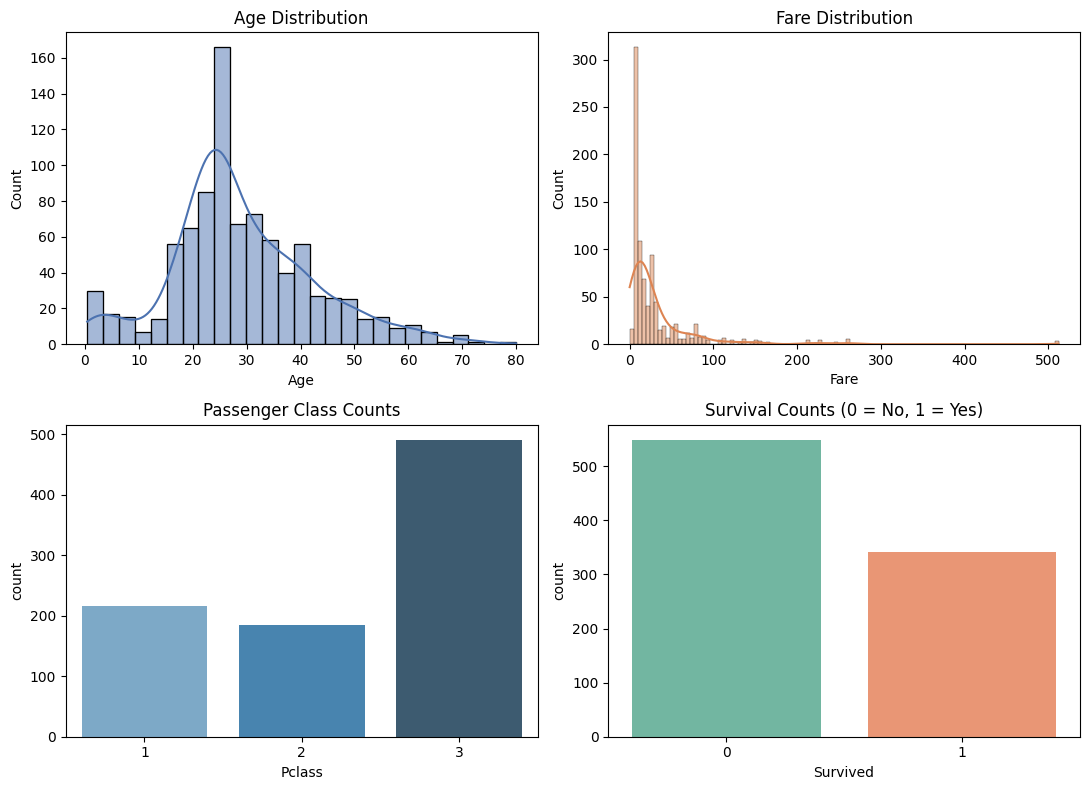

In [ ]:
# 5. UNIVARIATE ANALYSIS
summary_lines = []
summary_lines.append("=== UNIVARIATE SUMMARY ===")
summary_lines.append(str(df[["Age", "Fare", "FamilySize"]].describe()))
summary_lines.append(f"\nSurvival rate overall: {df['Survived'].mean():.2%}")
summary_lines.append(f"Sex distribution:\n{df['Sex'].value_counts(normalize=True)}")
summary_lines.append(f"Pclass distribution:\n{df['Pclass'].value_counts(normalize=True).sort_index()}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df["Age"], kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Age Distribution")
sns.histplot(df["Fare"], kde=True, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Fare Distribution")
sns.countplot(x="Pclass", data=df, ax=axes[1, 0], palette="Blues_d")
axes[1, 0].set_title("Passenger Class Counts")
sns.countplot(x="Survived", data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Survival Counts (0 = No, 1 = Yes)")
plt.tight_layout()
plt.savefig(f"{OUT}/01_univariate.png", dpi=110)
plt.show()

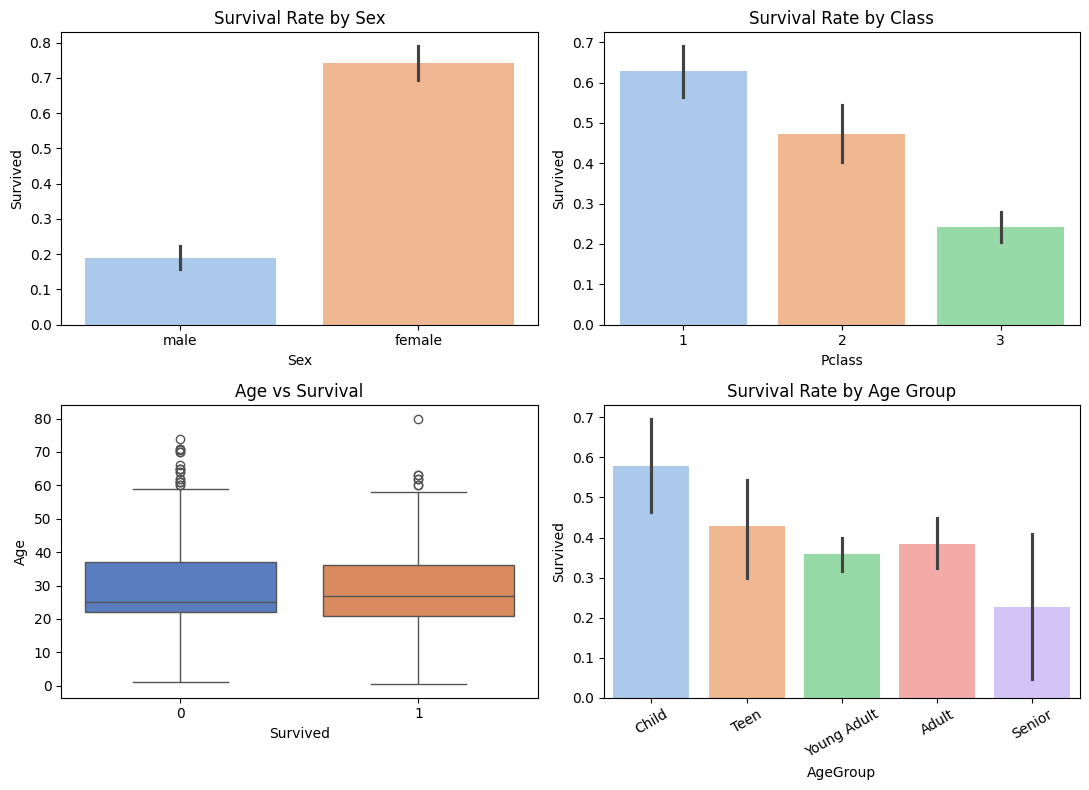

In [26]:
# 6. BIVARIATE ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0, 0], palette="pastel")
axes[0, 0].set_title("Survival Rate by Sex")
sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[0, 1], palette="pastel")
axes[0, 1].set_title("Survival Rate by Class")
sns.boxplot(x="Survived", y="Age", data=df, ax=axes[1, 0], palette="muted")
axes[1, 0].set_title("Age vs Survival")
sns.barplot(x="AgeGroup", y="Survived", data=df, ax=axes[1, 1], palette="pastel")
axes[1, 1].set_title("Survival Rate by Age Group")
axes[1, 1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{OUT}/02_bivariate.png", dpi=110)
plt.show()

Visualize correlations

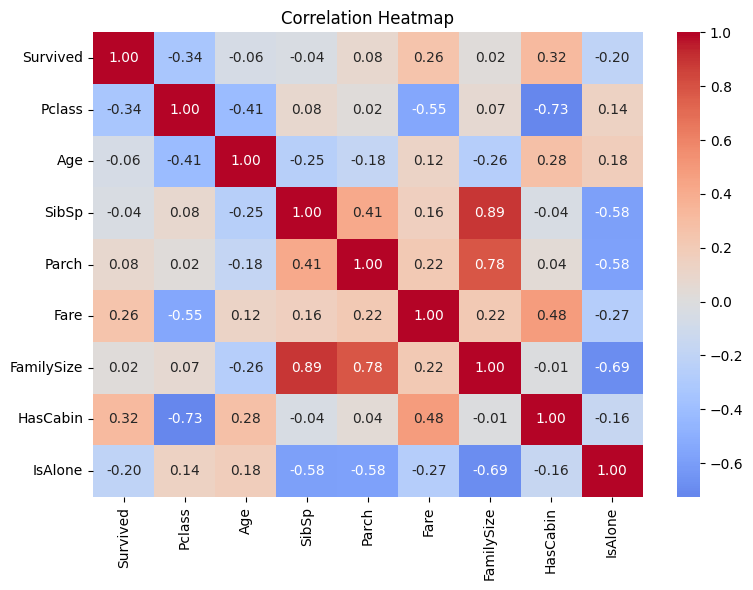

In [27]:
# 7. CORRELATION HEATMAP
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "HasCabin", "IsAlone"]
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUT}/03_correlation.png", dpi=110)
plt.show()